In [1]:
from datasets import load_dataset

dataset = load_dataset("Arsive/toxicity_classification_jigsaw")

df = dataset["train"].to_pandas()

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample:\n", df.head(3))
print("\nNull values:\n", df.isnull().sum())

LABELS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

d:\python_files\ann_project\new_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape: (25960, 8)

Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Sample:
                  id                                       comment_text  toxic  \
0  17dd17eb535029d6  "\n\nDear Jesus. Really, has Vander Plaats rea...      1   
1  9fc74022287f6325  You NDP attack queers, sorry, Cabal of Sanctim...      0   
2  1f64687358ed17f0  Tree thinking eliminates major swats of what e...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        1       0       1              1  
1             0        0       0       0              0  
2             0        0       0       0              0  

Null values:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


In [2]:
label_counts = df[LABELS].sum().sort_values(ascending=False)
label_pct    = (label_counts / len(df) * 100).round(2)

print(label_counts)

toxic            12233
obscene           6804
insult            6345
severe_toxic      1298
identity_hate     1124
threat             373
dtype: int64


In [3]:
print(label_pct)

toxic            47.12
obscene          26.21
insult           24.44
severe_toxic      5.00
identity_hate     4.33
threat            1.44
dtype: float64


In [4]:
import os
path = '../data/raw/data.csv'
os.makedirs(os.path.dirname(path), exist_ok=True)
df.to_csv(path, index=False)

In [5]:
clean_ratio = (df[LABELS].sum(axis=1) == 0).mean() * 100
print(f"\nClean (non-toxic) comments: {clean_ratio:.1f}%")
print(f"Toxic comments (any label): {100 - clean_ratio:.1f}%")


Clean (non-toxic) comments: 50.0%
Toxic comments (any label): 50.0%



Text length stats:
 count    25960.0
mean        60.9
std        105.1
min          1.0
25%         13.0
50%         29.0
75%         63.0
max       1403.0
Name: text_len, dtype: float64

Comments with >128 tokens (approx): 2660 (10.2%)


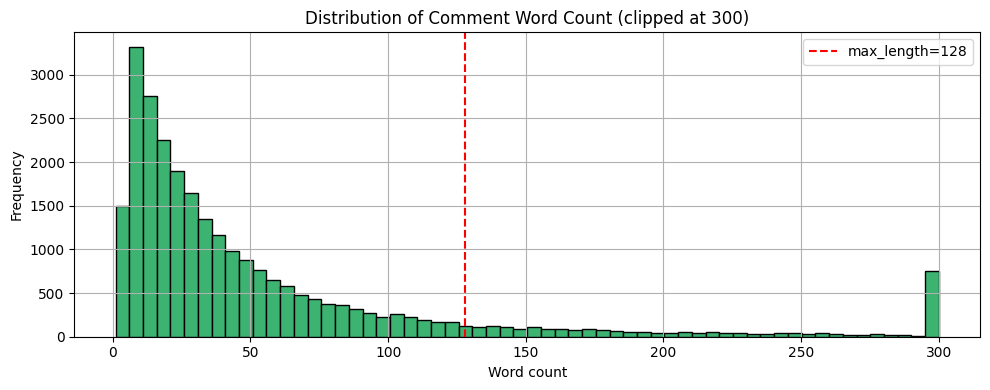

In [6]:
import matplotlib.pyplot as plt
df["text_len"] = df["comment_text"].str.split().str.len()

print("\nText length stats:\n", df["text_len"].describe().round(1))
print(f"\nComments with >128 tokens (approx): "
      f"{(df['text_len'] > 128).sum()} ({(df['text_len'] > 128).mean()*100:.1f}%)")

plt.figure(figsize=(10, 4))
df["text_len"].clip(upper=300).hist(bins=60, color="mediumseagreen", edgecolor="black")
plt.axvline(128, color="red", linestyle="--", label="max_length=128")
plt.title("Distribution of Comment Word Count (clipped at 300)")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("text_length.png", dpi=150)
plt.show()

In [7]:
pos_counts = df[LABELS].sum()
neg_counts  = len(df) - pos_counts
pos_weight  = (neg_counts / pos_counts).round(2)

print("\npos_weight per label (for BCEWithLogitsLoss):")
print(pos_weight.to_dict())


pos_weight per label (for BCEWithLogitsLoss):
{'toxic': 1.12, 'severe_toxic': 19.0, 'obscene': 2.82, 'threat': 68.6, 'insult': 3.09, 'identity_hate': 22.1}


In [8]:
df[LABELS].sum()

toxic            12233
severe_toxic      1298
obscene           6804
threat             373
insult            6345
identity_hate     1124
dtype: int64

In [9]:
neg_counts  = len(df) - pos_counts

In [10]:
neg_counts

toxic            13727
severe_toxic     24662
obscene          19156
threat           25587
insult           19615
identity_hate    24836
dtype: int64

In [ ]:
pos_weight  = (neg_counts / pos_counts).round(2)

print("\npos_weight per label (for BCEWithLogitsLoss):")
print(pos_weight.to_dict())


pos_weight per label (for BCEWithLogitsLoss):
{'toxic': 1.12, 'severe_toxic': 19.0, 'obscene': 2.82, 'threat': 68.6, 'insult': 3.09, 'identity_hate': 22.1}


In [12]:
df['text_len']

0         43
1         25
2         52
3        226
4        277
        ... 
25955     11
25956     26
25957      9
25958      4
25959      8
Name: text_len, Length: 25960, dtype: int64

In [16]:
print(len(df[df['text_len'] <= 128]))

23300
